
# Clasificador PLS vs Lenguaje Técnico (v2, criterios avanzados)
Este notebook cumple con:
- **Varios clasificadores binarios** para identificar lenguaje sencillo (PLS).
- **Embeddings contextuales** (Transformers) y **embeddings dispersos** (TF–IDF).
- **Distintas cabezas de clasificación**: lineal, **MLP**, y **ensamble** (promedio ponderado).
- **Evaluación rigurosa**: métricas (Accuracy, Precision, Recall, F1 macro, ROC-AUC, PR-AUC), **split train/val/test** y **validación cruzada** para modelos scikit-learn.


In [ ]:
!unzip bridging-the-gap-in-health-literacy-main.zip

In [ ]:
!pip install -U scikit-learn pandas numpy matplotlib joblib transformers datasets evaluate torch sentence-transformers pypdf2

In [ ]:
# --- Núcleo científico alineado con Colab / RAPIDS ---
%pip install -q \
  numpy==2.0.2 \
  pandas==2.2.2 \
  pyarrow==19.0.0 \
  scikit-learn==1.6.1

# --- PyTorch CUDA 12.6 (coincide con torchvision 0.23.0 de Colab) ---
%pip install -q --extra-index-url https://download.pytorch.org/whl/cu126 \
  torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0

# --- Hugging Face + métricas (satisface torchtune, peft y sentence-transformers) ---
%pip install -q \
  transformers==4.44.2 \
  tokenizers==0.19.1 \
  datasets==2.20.0 \
  accelerate==0.33.0 \
  evaluate==0.4.2

# --- Librerías que te estaban faltando (quedaban “no instaladas”) ---
%pip install -q \
  peft==0.17.1 \
  sentence-transformers==5.1.1 \
  fastai==2.8.4 \
  torchtune==0.6.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

# %pip install -U scikit-learn pandas numpy matplotlib joblib transformers datasets evaluate torch sentence-transformers pypdf2
import os, json, time, math, random, gc
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, roc_auc_score,
                             average_precision_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils import shuffle
from joblib import dump

print("Imports OK")

Imports OK


In [3]:
# === CONFIG ===
#BASE_DIR = Path('/content/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources')
BASE_DIR = Path('/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources')
OUTPUT_DIR = Path('./outputs_pls_classifier_v2'); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PARSE_PDFS = False
PDF_MIN_CHARS = 200

LABEL_BY_SOURCE_DEFAULT = {
    'Pfizer': 'pls',
    'Trial Summaries': 'pls',
    'ClinicalTrials.gov': 'non_pls'
}
LABEL_TO_INT = {'non_pls': 0, 'pls': 1}
INT_TO_LABEL = {0: 'non_pls', 1: 'pls'}

SOURCES = ['Cochrane','Pfizer','Trial Summaries','ClinicalTrials.gov']
RANDOM_STATE = 17
DEFAULT_TEST_SIZE = 0.2
VAL_SIZE = 0.15
DEDUPLICATE = True

print('BASE_DIR =', BASE_DIR.resolve())
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())

BASE_DIR = /Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources
OUTPUT_DIR = /Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/med-plain-language-summarizer/models/outputs_pls_classifier_v2


In [4]:
def read_txt_file(path: Path) -> Optional[str]:
    try:
        t = path.read_text(encoding='utf-8', errors='ignore').strip()
        return t if t else None
    except Exception:
        return None

def iter_texts_in_dir(root: Path, exts=('.txt',)) -> List[Path]:
    return [p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in exts]

def normalize_for_dedup(s: str) -> str:
    return ' '.join((s or '').lower().split())

def load_cochrane(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Cochrane'
    if not root.exists(): return out
    for subset in ['train','test']:
        for cls in ['pls','non_pls']:
            cdir = root / subset / cls
            if not cdir.exists(): continue
            for p in iter_texts_in_dir(cdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':cls,'source':'Cochrane','subset':subset,'path':str(p)})
    return out

def load_pfizer(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Pfizer'
    if not root.exists(): return out
    for subset in ['train','test']:
        sdir = root / subset
        if sdir.exists():
            for p in iter_texts_in_dir(sdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Pfizer','pls'),
                                'source':'Pfizer','subset':subset,'path':str(p)})
    return out

def load_trial_summaries(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Trial Summaries'
    if not root.exists(): return out
    for tf in ['med','alx']:
        tfdir = root / tf
        if tfdir.exists():
            for p in iter_texts_in_dir(tfdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('Trial Summaries','pls'),
                                'source':'Trial Summaries','subset':'unspecified','path':str(p)})
    return out

def load_clinicaltrials_gov(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'ClinicalTrials.gov'
    if not root.exists(): return out
    for subset in ['train','test']:
        sdir = root / subset
        if sdir.exists():
            for p in iter_texts_in_dir(sdir):
                t = read_txt_file(p)
                if t:
                    out.append({'text':t,'label':LABEL_BY_SOURCE_DEFAULT.get('ClinicalTrials.gov','non_pls'),
                                'source':'ClinicalTrials.gov','subset':subset,'path':str(p)})
    return out

def load_all(base_dir: Path, sources: List[str]) -> pd.DataFrame:
    recs = []
    if 'Cochrane' in sources: recs += load_cochrane(base_dir)
    if 'Pfizer' in sources: recs += load_pfizer(base_dir)
    if 'Trial Summaries' in sources: recs += load_trial_summaries(base_dir)
    if 'ClinicalTrials.gov' in sources: recs += load_clinicaltrials_gov(base_dir)
    df = pd.DataFrame(recs)
    if df.empty:
        print('⚠️ No se encontraron textos. Revisa rutas.')
        return df
    df['label_int'] = df['label'].map({'non_pls':0,'pls':1})
    df['subset'] = df['subset'].fillna('unspecified')
    df['n_chars'] = df['text'].str.len()
    return df

df_raw = load_all(BASE_DIR, SOURCES)
print('Total textos:', len(df_raw))
df_raw.head(3)

Total textos: 61363


,text,label,source,subset,path,label_int,n_chars
0,Aquatic exercise training for fibromyalgia\nRe...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2792
1,Immunonutrition for acute respiratory distress...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2156
2,"Exercise interventions for improving activity,...",pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2676


Deduplicación: 61363 -> 61325 (elim 38)

Etiquetas:
label
non_pls    39525
pls        21800
Name: count, dtype: int64

Fuentes:
source
Cochrane              58940
Trial Summaries        1034
ClinicalTrials.gov      751
Pfizer                  600
Name: count, dtype: int64


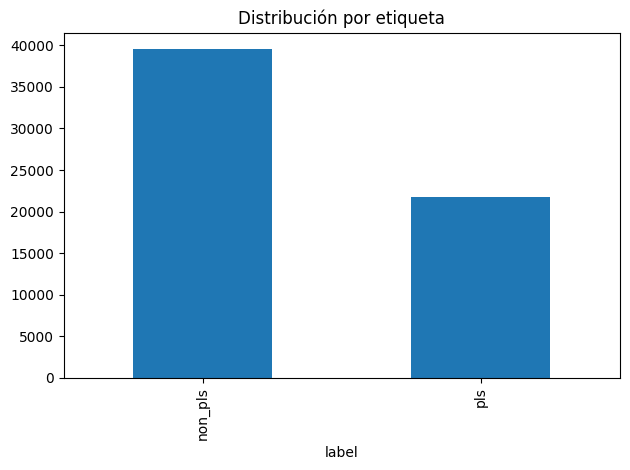

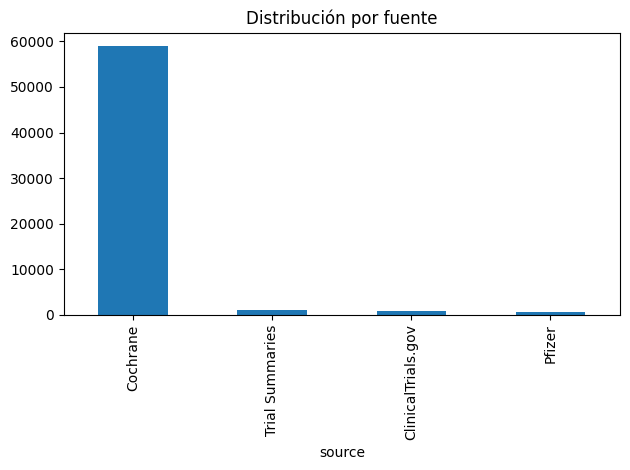

In [5]:
df = df_raw.copy()
if not df.empty and DEDUPLICATE:
    before = len(df)
    key = df['text'].map(normalize_for_dedup)
    df = df.loc[~key.duplicated()].reset_index(drop=True)
    after = len(df)
    print(f'Deduplicación: {before} -> {after} (elim {before-after})')
else:
    print('Deduplicación desactivada o DF vacío.')

print('\nEtiquetas:'); print(df['label'].value_counts())
print('\nFuentes:'); print(df['source'].value_counts())

plt.figure()
df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución por etiqueta')
plt.tight_layout(); plt.show()

plt.figure()
df['source'].value_counts().plot(kind='bar')
plt.title('Distribución por fuente')
plt.tight_layout(); plt.show()

In [14]:
df_raw.head(10)

,text,label,source,subset,path,label_int,n_chars
0,Aquatic exercise training for fibromyalgia\nRe...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2792
1,Immunonutrition for acute respiratory distress...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2156
2,"Exercise interventions for improving activity,...",pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2676
3,Bronchial thermoplasty for people with asthma\...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2508
4,Do interventions that reduce the cost of smoki...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2901
5,Intensive case management for people with seve...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,1602
6,Oral water soluble contrast for cancer‐related...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2919
7,Addition of long‐acting beta2‐agonists to inha...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,1573
8,Which drug is best for reducing excessive bloo...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2624
9,Methods of milk expression for lactating women...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Stud...,1,2220


In [15]:
import re
import pandas as pd
import numpy as np
from pathlib import Path

# Intentar cargar bits de sklearn; si no están, el notebook sigue funcionando sin chi2/NMI
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.feature_selection import chi2
    from sklearn.metrics import normalized_mutual_info_score
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False

# -------- Patrones de marcadores --------
PLS_REGEXES = [
    r"\bplain[-\s]?language summary\b",
    r"\blay summary\b",
    r"\bplain[-\s]?english\b",
    r"\bsummary in plain english\b",
    r"\bthis (?:is|provides) (?:a )?plain[-\s]?language\b",
    # Encabezados típicos PLS (Cochrane)
    r"\bwhat is the aim of this review\?",
    r"\bwhat was studied in this review\?",
    r"\bwhat did (?:the authors|researchers|we) (?:do|find)\?",
    r"\bhow reliable (?:are|is) (?:these|the) results\?",
    r"\bwhat does this mean\?",
]

TECH_REGEXES = [
    r"\bNCT\d{8}\b",
    r"\bEudraCT\s*\d{4}-\d{6}-\d{2}\b",
    r"clinicaltrials\.gov",
    r"\bphase\s*[IVX]+\b",
    r"\brandomi[sz]ed\b",
    r"\bdouble[-\s]?blind\b",
    r"\bodds ratio\b",
    r"\b95%\s*CI\b",
    r"\bp\s*[<=>]\s*0\.\d+\b",
    r"\bintention[-\s]?to[-\s]?treat\b",
    r"\binclusion criteria\b",
    r"\bexclusion criteria\b",
    r"\bp[-\s]?value\b",
    r"\binterventional\b",
    r"\bprimary endpoint\b",
    r"\bplacebo[-\s]?controlled\b",
]

SOURCE_REGEXES = [
    r"\bcochrane\b",
    r"\bpfizer\b",
    r"\btrial summaries?\b",
    r"\bclinicaltrials\.gov\b",
    r"\bema\b",
]

# Cues literales de etiqueta — jamás deberían aparecer
LABEL_CUES = [
    r"\bpls\b",
    r"\bnon[-\s]?pls\b",
    r"\blay\b",
]

def _compile_list(regex_list):
    return [re.compile(rx, flags=re.I) for rx in regex_list]

PLS_PATTERNS    = _compile_list(PLS_REGEXES)
TECH_PATTERNS   = _compile_list(TECH_REGEXES)
SOURCE_PATTERNS = _compile_list(SOURCE_REGEXES)
LABEL_PATTERNS  = _compile_list(LABEL_CUES)

def any_match(text, patterns):
    if not isinstance(text, str):
        return False
    return any(p.search(text) for p in patterns)

def count_matches(text, patterns):
    if not isinstance(text, str):
        return 0
    return sum(1 for p in patterns if p.search(text))

def scan_dataframe(df, text_col, path_col=None, source_col=None):
    s = df[text_col].astype(str).str.lower()
    out = df.copy()

    out["has_pls_marker"]    = s.apply(lambda x: any_match(x, PLS_PATTERNS))
    out["has_tech_marker"]   = s.apply(lambda x: any_match(x, TECH_PATTERNS))
    out["pls_marker_count"]  = s.apply(lambda x: count_matches(x, PLS_PATTERNS))
    out["tech_marker_count"] = s.apply(lambda x: count_matches(x, TECH_PATTERNS))
    out["text_has_label_literal"] = s.apply(lambda x: any_match(x, LABEL_PATTERNS))

    if path_col and path_col in df.columns:
        p = df[path_col].astype(str).str.lower()
        out["path_has_pls_literal"] = (
            p.str.contains(r"\bpls\b", regex=True) |
            p.str.contains("non_pls") | p.str.contains("non-pls")
        )
    else:
        out["path_has_pls_literal"] = False

    if source_col and source_col in df.columns:
        sc = df[source_col].astype(str).str.lower()
        out["source_has_marker"] = sc.apply(lambda x: any_match(x, SOURCE_PATTERNS))
    else:
        out["source_has_marker"] = False

    return out

def nmi_source_label(df, source_col, label_col):
    if not SKLEARN_OK or source_col not in df.columns:
        return None
    s = df[source_col].astype("category").cat.codes.values
    y = df[label_col].astype("category").cat.codes.values
    return normalized_mutual_info_score(s, y)

def chi2_top_terms(df, text_col, label_col, top_k=30):
    if not SKLEARN_OK:
        return None, None
    vect = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.95, sublinear_tf=True)
    X = vect.fit_transform(df[text_col].astype(str))
    y = df[label_col].astype("category").cat.codes.values
    chi2_vals, _ = chi2(X, y)
    terms = np.array(vect.get_feature_names_out())
    order = np.argsort(chi2_vals)
    top_overall    = terms[order[-top_k:]][::-1]
    bottom_overall = terms[order[:top_k]]
    return top_overall, bottom_overall


In [17]:
print("=== BY LABEL (rates) ===")
by_label = {}
for col in ["has_pls_marker", "has_tech_marker", "text_has_label_literal"]:
    rates = scanned.groupby("label")[col].mean().sort_values(ascending=False)
    by_label[col] = (rates * 100).round(2).astype(str) + "%"
    print(f"\n{col}:\n{by_label[col].to_string()}")

print("\n=== SOURCE × LABEL CROSSTAB ===")
ct = pd.crosstab(scanned["source"], scanned["label"])
display(ct)

nmi = nmi_source_label(scanned, "source", "label")
print(f"\nNMI(source,label): {nmi:.4f}" if nmi is not None else "\nNMI(source,label): (no disponible)")


=== BY LABEL (rates) ===

has_pls_marker:
label
pls        19.11%
non_pls     0.02%

has_tech_marker:
label
non_pls    95.45%
pls        39.77%

text_has_label_literal:
label
pls        0.49%
non_pls    0.41%

=== SOURCE × LABEL CROSSTAB ===


label,non_pls,pls
source,,
ClinicalTrials.gov,760,0
Cochrane,38782,20181
Pfizer,0,606
Trial Summaries,0,1034



NMI(source,label): 0.0780


In [18]:
pd.set_option("display.max_colwidth", 220)

def preview(mask, title, cols=("text","label","source","path"), n=5):
    sub = scanned.loc[mask, cols].head(n).copy()
    if "text" in sub.columns:
        sub["text"] = sub["text"].astype(str).str.slice(0, 200) + "…"
    if len(sub) == 0:
        print(f"\n=== PREVIEW: {title} — (0 filas) ===")
    else:
        print(f"\n=== PREVIEW: {title} — (n={len(sub)}) ===")
        display(sub)

preview(scanned["text_has_label_literal"], "Texto contiene literal de etiqueta (pls/non-pls/lay)")
preview(scanned["has_pls_marker"],          "Texto con marcadores PLS (e.g., 'plain language summary', headers Cochrane)")
preview(scanned["has_tech_marker"],         "Texto con marcadores técnicos (NCT, p-values, etc.)")
preview(scanned["path_has_pls_literal"],    "Ruta con 'pls' o 'non_pls'")



=== PREVIEW: Texto contiene literal de etiqueta (pls/non-pls/lay) — (n=5) ===


,text,label,source,path
196,Prescribing roles for health professionals other than doctors\nWhat is the aim of this review? \nThe aim of this Cochrane review was to find out if prescribing by health professionals other than doctors…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD011227.pub2-pls.txt...
348,"Perceptions and experiences of labour companionship\nWhat is the aim of this synthesis? \nThe aim of this Cochrane qualitative evidence synthesis was to explore how women, families, and health workers e…",pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD012449.pub2-pls.txt...
625,Patient and lay carer education for preventing pressure ulceration in at‐risk populations\nWhat is the aim of this review? \nThe aim of this review was to find out whether education programmes aimed at …,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD012006.pub2-pls.txt
669,First aid treatments for oral poisoning\nReview question \nWe reviewed the evidence on the effects of first aid treatments for poisoning that could be feasibly given by people who are not health profess…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD013230-pls.txt
849,Factors that can influence the success of lay health worker programmes for maternal and child health \nThis review was carried out by researchers in The Cochrane Collaboration. It summarises the findin…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD010414.pub2-pls.txt...



=== PREVIEW: Texto con marcadores PLS (e.g., 'plain language summary', headers Cochrane) — (n=5) ===


,text,label,source,path
12,"Do beds, mattresses and mattress toppers that apply constant pressure to the skin and are not air‐filled or made of foam prevent pressure ulcers? \nKey messages \nDue to a lack of robust evidence, it is…",pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD013623.pub2-pls.txt...
17,"Punctal plugs for dry eye syndrome\nWhat is the aim of this review? The aim of this Cochrane Review was to determine whether punctal plugs, which are inserted into the tear ducts to block tear drainag…",pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD006775.pub3-pls.txt
30,Topical medicine instillation techniques for glaucoma\nWhat is the aim of this review? The aim of this Cochrane Review was to find out if the way that people with glaucoma put eye drops in makes a dif…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD010520.pub2-pls.txt...
50,Anti‐VEGF for treatment of choroidal neovascularisation (new blood vessels) in people with pathological (severe) myopia \nWhat is the aim of this review? The aim of this Cochrane Review was to find ou…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD011160.pub2-pls.txt...
53,"Tests to detect and inform the diagnosis of root caries\nWhy is it important to improve root caries detection? \nRoot caries (tooth decay on the root of a tooth) is a well‐recognised disease, that is on…",pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD013806-pls.txt_accu...



=== PREVIEW: Texto con marcadores técnicos (NCT, p-values, etc.) — (n=5) ===


,text,label,source,path
5,"Intensive case management for people with severe mental illness\nBackground \nSevere mental illnesses are defined by diagnosis, degree of disability and the presence of some abnormal behaviour. Includin…",pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD007906.pub3-pls.txt...
24,Mindfulness for improving mental well‐being in medical students and junior doctors\nWhy is this review important? \nThe medical profession is recognised for its challenging and demanding nature. Medical…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD013740.pub2-pls.txt...
25,Surgery for women with pelvic organ prolapse with or without continence procedures\nReview question \nTo assess the outcomes of operations for pelvic organ prolapse (POP) with or without operations to t…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD013108-pls.txt_accu...
26,Antibiotic therapy for the treatment of methicillin‐resistant Staphylococcus aureus (MRSA) infections in people with surgical wounds \nSome people having surgery develop wound infections. These are usu…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD009726.pub2-pls.txt
28,Azapirones versus placebo for panic disorder in adults\nWhy is this review important? \nPanic disorder is common in the general population and is often associated with various psychiatric disorders. Aza…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD010828.pub2-pls.txt...



=== PREVIEW: Ruta con 'pls' o 'non_pls' — (n=5) ===


,text,label,source,path
0,"Aquatic exercise training for fibromyalgia\nResearch question \nWe reviewed studies on the effects of aquatic exercise training for people with fibromyalgia on wellness, symptoms, fitness, and adverse e…",pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD011336-pls.txt_accu...
1,Immunonutrition for acute respiratory distress syndrome (ARDS) in adults\nBackground \nAcute respiratory distress syndrome (ARDS) is a life‐threatening condition wherein the lungs are inflamed (irritate…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD012041.pub2-pls.txt
2,"Exercise interventions for improving activity, participation and quality of life in people with cerebral palsy \nReview question \nDoes exercise improve activity, participation in life situations and qu…",pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD011660.pub2-pls.txt...
3,Bronchial thermoplasty for people with asthma\nReview question \nWe reviewed the effects of bronchial thermoplasty in people with asthma.\nBackground \nAsthma is a chronic condition in which people experi…,pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD009910.pub2-pls.txt...
4,"Do interventions that reduce the cost of smoking cessation treatment increase quit rates, quit attempts or use of treatments? \nBackground \nInterventions that reduce or cover the costs of smoking cessa…",pls,Cochrane,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD004305.pub5-pls.txt


In [19]:
if SKLEARN_OK:
    print("=== CHI² TOP FEATURES (inspecciona términos sospechosos de fuga) ===")
    top_terms, bottom_terms = chi2_top_terms(scanned, text_col="text", label_col="label", top_k=30)
    if top_terms is not None:
        print("\nTop (overall):\n", ", ".join(top_terms))
        print("\nBottom (overall):\n", ", ".join(bottom_terms))
else:
    print("scikit-learn no disponible — se omite análisis chi²/NMI.")


=== CHI² TOP FEATURES (inspecciona términos sospechosos de fuga) ===

Top (overall):
 what, ci, 95, 95 ci, how, question, rr, review question, key results, find, study characteristics, what is, find out, the cochrane, data, to find, register, key, central, did we, wanted to, wanted, called, analysis, selection, characteristics we, criteria, objectives, search methods, selection criteria

Bottom (overall):
 strabismus and, controversial issue, with retinal, free amino, caution it, hypertension mmhg, of 782, and adhesions, pallor, disease outcomes, to pneumoniae, or melatonin, physical pain, pre injury, severe copd, or azathioprine, sinusitis or, that penicillin, withdrawal tapering, management further, five treatments, suspicious ovarian, nine primary, streams irrigation, irrigation ditches, ditches and, ditches, medicinal plant, or banning, schools may


In [16]:
scanned = scan_dataframe(df_raw, text_col="text", path_col="path", source_col="source")

# Resumen global
total = len(scanned)
flag_cols = ["has_pls_marker", "has_tech_marker", "text_has_label_literal",
             "path_has_pls_literal", "source_has_marker"]

summary = (
    scanned[flag_cols]
    .mean()
    .rename("rate")
    .to_frame()
)
summary["count"] = [scanned[c].sum() for c in flag_cols]
summary["rate"] = (summary["rate"] * 100).round(2).astype(str) + "%"

print("=== FLAG SUMMARY ===")
summary


=== FLAG SUMMARY ===


,rate,count
has_pls_marker,6.81%,4177
has_tech_marker,75.65%,46423
text_has_label_literal,0.44%,268
path_has_pls_literal,97.08%,59569
source_has_marker,100.0%,61363


In [25]:
def any_match_list(text: str, regex_list) -> bool:
    if not isinstance(text, str):
        return False
    return any(re.search(rx, text, flags=re.I) for rx in regex_list)

In [28]:
# Requiere df_raw con: text, label, source, subset, path, label_int, n_chars
required = {"text","label","source","subset","path","label_int","n_chars"}
assert required.issubset(df_raw.columns), f"Faltan columnas: {sorted(list(required - set(df_raw.columns)))}"

df = df_raw.copy()

# Flags PRE-limpieza (solo texto)
s_lower = df["text"].astype(str).str.lower()
df["risk_text_has_label_literal"] = s_lower.apply(lambda x: any_match_list(x, LABEL_CUES))
df["risk_has_pls_marker"]        = s_lower.apply(lambda x: any_match_list(x, PLS_REGEXES))

# Limpiar **únicamente** en el texto: enmascarar marcadores PLS y literales de etiqueta
text_clean = s_lower.copy()
for rx in (PLS_REGEXES + LABEL_CUES):
    text_clean = text_clean.str.replace(rx, " ", regex=True)
text_clean = text_clean.str.replace(r"\s+", " ", regex=True).str.strip()
df["text_clean"] = text_clean

# Flags POST-limpieza (solo sobre text_clean)
df["risk_pls_marker_after"]     = df["text_clean"].apply(lambda x: any_match_list(x, PLS_REGEXES))
df["risk_label_literal_after"]  = df["text_clean"].apply(lambda x: any_match_list(x, LABEL_CUES))

# Resumen de limpieza (tasa antes vs. después, sin eliminar filas por path)
before_pls   = df["risk_has_pls_marker"].mean()
after_pls    = df["risk_pls_marker_after"].mean()
before_label = df["risk_text_has_label_literal"].mean()
after_label  = df["risk_label_literal_after"].mean()

print("=== VERIFICACIÓN SOLO-TEXTO ===")
print(f"PLS markers  (antes): {before_pls:.2%}")
print(f"PLS markers  (después, text_clean): {after_pls:.2%}")
print(f"Label literal (antes): {before_label:.2%}")
print(f"Label literal (después, text_clean): {after_label:.2%}")

# (Opcional) guarda el dataset limpio para entrenamiento (usar 'text_clean')
# df.to_csv("dataset_pls_clean_text_only.csv", index=False)


=== VERIFICACIÓN SOLO-TEXTO ===
PLS markers  (antes): 6.81%
PLS markers  (después, text_clean): 0.01%
Label literal (antes): 0.44%
Label literal (después, text_clean): 0.00%


In [27]:
# Tabla de recuento por fuente y etiqueta usando df_clean
tabla_fuente = (
    df_clean
    .groupby(["source", "label"])
    .size()
    .rename("count")
    .reset_index()
    .pivot_table(index="source", columns="label", values="count", fill_value=0)
    .sort_index()
)

print("=== RESUMEN POR FUENTE (post-limpieza) ===")
display(tabla_fuente)

# (Opcional) Totales
totales = tabla_fuente.sum(axis=0).to_frame("count_total").T
display(totales)

# (Opcional) Guardar dataset limpio
# df_clean.to_csv("dataset_pls_clean.csv", index=False)


=== RESUMEN POR FUENTE (post-limpieza) ===


label,non_pls,pls
source,,
ClinicalTrials.gov,760.0,0.0
Trial Summaries,0.0,1031.0


label,non_pls,pls
count_total,760.0,1031.0


In [31]:
df.head(3)

,text,label,source,subset,path,label_int,n_chars,risk_text_has_label_literal,risk_has_pls_marker,text_clean,risk_pls_marker_after,risk_label_literal_after
0,"Aquatic exercise training for fibromyalgia\nResearch question \nWe reviewed studies on the effects of aquatic exercise training for people with fibromyalgia on wellness, symptoms, fitness, and adverse effects. \nBack...",pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD011336-pls.txt_accu...,1,2792,False,False,"aquatic exercise training for fibromyalgia research question we reviewed studies on the effects of aquatic exercise training for people with fibromyalgia on wellness, symptoms, fitness, and adverse effects. backgroun...",False,False
1,Immunonutrition for acute respiratory distress syndrome (ARDS) in adults\nBackground \nAcute respiratory distress syndrome (ARDS) is a life‐threatening condition wherein the lungs are inflamed (irritated) and damaged...,pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD012041.pub2-pls.txt,1,2156,False,False,immunonutrition for acute respiratory distress syndrome (ards) in adults background acute respiratory distress syndrome (ards) is a life‐threatening condition wherein the lungs are inflamed (irritated) and damaged. i...,False,False
2,"Exercise interventions for improving activity, participation and quality of life in people with cerebral palsy \nReview question \nDoes exercise improve activity, participation in life situations and quality of life ...",pls,Cochrane,train,/Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources/Cochrane/train/pls/10.1002-14651858.CD011660.pub2-pls.txt...,1,2676,False,False,"exercise interventions for improving activity, participation and quality of life in people with cerebral palsy review question does exercise improve activity, participation in life situations and quality of life in p...",False,False


In [32]:
def make_splits(df: pd.DataFrame, test_size=0.2, val_size=0.15, random_state=17):
    has_split = df['subset'].isin(['train','test']).any()
    if has_split:
        train_df = df[df['subset']=='train'].copy()
        test_df  = df[df['subset']=='test'].copy()
        uns = df[df['subset']=='unspecified'].copy()
        parts_tr = [train_df]; parts_te = [test_df]
        if not uns.empty:
            for src, g in uns.groupby('source'):
                if g['label_int'].nunique()<2 or len(g) < 10:
                    parts_tr.append(g)
                else:
                    gtr, gte = train_test_split(g, test_size=test_size, stratify=g['label_int'], random_state=random_state)
                    parts_tr.append(gtr); parts_te.append(gte)
        train_df = pd.concat(parts_tr, ignore_index=True)
        test_df  = pd.concat(parts_te, ignore_index=True)
    else:
        train_df, test_df = train_test_split(df, test_size=test_size, stratify=df['label_int'], random_state=random_state)
    if val_size and val_size>0:
        tr_df, val_df = train_test_split(train_df, test_size=val_size, stratify=train_df['label_int'], random_state=random_state)
    else:
        tr_df, val_df = train_df, pd.DataFrame()
    tr_df = shuffle(tr_df, random_state=random_state).reset_index(drop=True)
    val_df = shuffle(val_df, random_state=random_state).reset_index(drop=True)
    test_df = shuffle(test_df, random_state=random_state).reset_index(drop=True)
    return tr_df, val_df, test_df

df_train, df_val, df_test = make_splits(df, test_size=0.2, val_size=0.15, random_state=17)
print('Sizes -> train:', len(df_train), 'val:', len(df_val), 'test:', len(df_test))
for name, d in [('train',df_train),('val',df_val),('test',df_test)]:
    print(f"\n{name} por etiqueta:"); print(d['label'].value_counts())

Sizes -> train: 42079 val: 7426 test: 11858

train por etiqueta:
label
non_pls    26979
pls        15100
Name: count, dtype: int64

val por etiqueta:
label
non_pls    4761
pls        2665
Name: count, dtype: int64

test por etiqueta:
label
non_pls    7802
pls        4056
Name: count, dtype: int64


=== Estadísticos n_chars por clase ===
PLS : {'n': 21821, 'mean': 2677.303239998167, 'std': 927.9644996326159, 'p10': 1727.0, 'p25': 1989.0, 'p50': 2485.0, 'p75': 3210.0, 'p90': 3994.0}
NoPLS: {'n': 39542, 'mean': 3576.8981336300644, 'std': 1587.7955904324058, 'p10': 2001.0, 'p25': 2410.0, 'p50': 3239.0, 'p75': 4453.75, 'p90': 5538.0}

=== Estadísticos n_words por clase ===
PLS : {'n': 21821, 'mean': 415.237111039824, 'std': 146.84642382461, 'p10': 267.0, 'p25': 306.0, 'p50': 384.0, 'p75': 498.0, 'p90': 623.0}
NoPLS: {'n': 39542, 'mean': 527.2744423650802, 'std': 244.53398614796487, 'p10': 287.0, 'p25': 348.0, 'p50': 474.0, 'p75': 661.0, 'p90': 827.0}

=== KS test ===
n_chars: statistic=0.2582, pvalue=0.000e+00
n_words: statistic=0.2168, pvalue=0.000e+00

=== Tamaño de efecto (Cohen's d) ===
n_chars d = -0.647  (≈0.2 pequeño, ≈0.5 medio, ≈0.8 grande)
n_words d = -0.521

=== Prevalencia PLS por cuartiles de n_chars ===


/var/folders/2q/p17m4gr51m3fhz0vkcd3cfmw0000gn/T/ipykernel_7573/2075804213.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev_by_q = (data.groupby('len_quartile')['label_bin']
/var/folders/2q/p17m4gr51m3fhz0vkcd3cfmw0000gn/T/ipykernel_7573/2075804213.py:89: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev_by_q['count'] = data.groupby('len_quartile')['label_bin'].size()


,PLS_rate,count
len_quartile,,
"(208.999, 2226.0]",0.531848,15354
"(2226.0, 2901.0]",0.410810,15338
"(2901.0, 4001.0]",0.338898,15335
"(4001.0, 28992.0]",0.140649,15336



=== Clasificador baseline SOLO longitud (log1p(n_chars), log1p(n_words)) ===
ROC-AUC (5-fold)   : 0.849 ± 0.003
PR-AUC  (5-fold)   : 0.766 ± 0.007
Brier   (5-fold)   : 0.147 ± 0.001


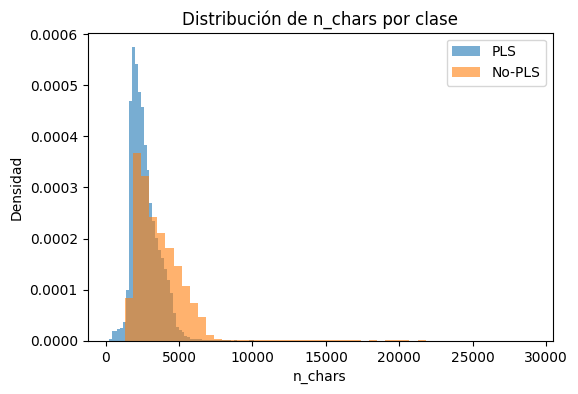

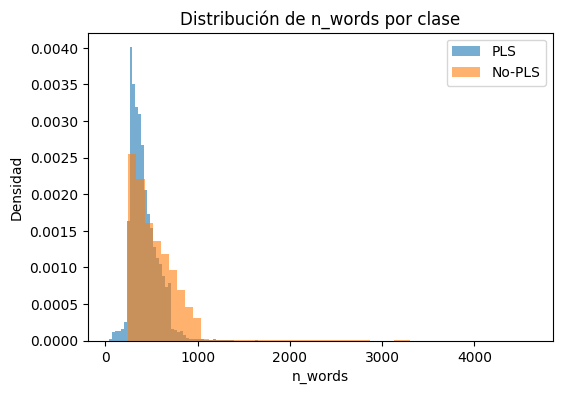


=== Evaluación de riesgo de sesgo por longitud (heurística) ===
- La longitud en caracteres muestra diferencias estadística/prácticamente relevantes entre clases.
- La longitud en palabras muestra diferencias estadística/prácticamente relevantes entre clases.
- Un clasificador basado SOLO en longitud obtiene AUC ≥ 0.80 → alto riesgo de sesgo por longitud.


In [23]:
# 🔍 Longitud (n_chars / n_words) vs. etiqueta (PLS / No-PLS): ¿puede sesgar el modelo?
# - Compara distribuciones por clase (estadísticos, KS test, tamaño de efecto)
# - Evalúa un clasificador baseline SOLO con longitud para estimar su poder predictivo (ROC-AUC, PR-AUC)
# - Muestra prevalencia PLS por cuartiles de longitud
# - (Opcional) Grafica histogramas separados por clase

import numpy as np
import pandas as pd

from scipy.stats import ks_2samp
try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False

import matplotlib.pyplot as plt

# ----------- Helpers -----------
def _cohens_d(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2: 
        return np.nan
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    s = np.sqrt(((nx-1)*vx + (ny-1)*vy) / (nx + ny - 2))
    if s == 0:
        return 0.0
    return (np.mean(x) - np.mean(y)) / s

def _summ_stats(arr):
    q = np.quantile(arr, [0.1, 0.25, 0.5, 0.75, 0.9])
    return {
        "n": int(arr.size),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr, ddof=1)) if arr.size>1 else 0.0,
        "p10": float(q[0]),
        "p25": float(q[1]),
        "p50": float(q[2]),
        "p75": float(q[3]),
        "p90": float(q[4]),
    }

# ----------- Data selection -----------
data = scanned.copy()


# Normaliza columnas mínimas requeridas
if 'text' not in data.columns or 'label' not in data.columns:
    raise ValueError("Se requieren columnas 'text' y 'label'.")

# ----------- Longitudes -----------
if 'n_chars' not in data.columns:
    data['n_chars'] = data['text'].astype(str).str.len()

data['n_words'] = data['text'].astype(str).str.split().str.len()
data['label_bin'] = (data['label'].astype(str).str.lower() == 'pls').astype(int)

pls_mask = data['label_bin'] == 1
non_mask = ~pls_mask

# ----------- Estadísticos por clase -----------
chars_pls = data.loc[pls_mask, 'n_chars'].values
chars_non = data.loc[non_mask, 'n_chars'].values
words_pls = data.loc[pls_mask, 'n_words'].values
words_non = data.loc[non_mask, 'n_words'].values

stats_chars_pls = _summ_stats(chars_pls)
stats_chars_non = _summ_stats(chars_non)
stats_words_pls = _summ_stats(words_pls)
stats_words_non = _summ_stats(words_non)

# KS tests
ks_chars = ks_2samp(chars_pls, chars_non, alternative='two-sided', mode='auto')
ks_words = ks_2samp(words_pls, words_non, alternative='two-sided', mode='auto')

# Tamaño de efecto (Cohen's d): positivo => PLS más largos; negativo => PLS más cortos
d_chars = _cohens_d(chars_pls, chars_non)
d_words = _cohens_d(words_pls, words_non)

# ----------- Prevalencia PLS por cuartiles de longitud -----------
data['len_quartile'] = pd.qcut(data['n_chars'], q=4, duplicates='drop')
prev_by_q = (data.groupby('len_quartile')['label_bin']
                .mean()
                .rename('PLS_rate')
                .to_frame())
prev_by_q['count'] = data.groupby('len_quartile')['label_bin'].size()

print("=== Estadísticos n_chars por clase ===")
print("PLS :", stats_chars_pls)
print("NoPLS:", stats_chars_non)

print("\n=== Estadísticos n_words por clase ===")
print("PLS :", stats_words_pls)
print("NoPLS:", stats_words_non)

print("\n=== KS test ===")
print(f"n_chars: statistic={ks_chars.statistic:.4f}, pvalue={ks_chars.pvalue:.3e}")
print(f"n_words: statistic={ks_words.statistic:.4f}, pvalue={ks_words.pvalue:.3e}")

print("\n=== Tamaño de efecto (Cohen's d) ===")
print(f"n_chars d = {d_chars:.3f}  (≈0.2 pequeño, ≈0.5 medio, ≈0.8 grande)")
print(f"n_words d = {d_words:.3f}")

print("\n=== Prevalencia PLS por cuartiles de n_chars ===")
display(prev_by_q)

# ----------- Baseline de sesgo: ¿Longitud sola predice la etiqueta? -----------
if SKLEARN_OK:
    X = np.c_[np.log1p(data['n_chars'].values), np.log1p(data['n_words'].values)]
    y = data['label_bin'].values

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs, aps, briers = [], [], []
    for train_idx, test_idx in skf.split(X, y):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]
        clf = LogisticRegression(max_iter=200, n_jobs=None)
        clf.fit(Xtr, ytr)
        p = clf.predict_proba(Xte)[:,1]
        aucs.append(roc_auc_score(yte, p))
        aps.append(average_precision_score(yte, p))
        briers.append(brier_score_loss(yte, p))
    print("\n=== Clasificador baseline SOLO longitud (log1p(n_chars), log1p(n_words)) ===")
    print(f"ROC-AUC (5-fold)   : {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
    print(f"PR-AUC  (5-fold)   : {np.mean(aps):.3f} ± {np.std(aps):.3f}")
    print(f"Brier   (5-fold)   : {np.mean(briers):.3f} ± {np.std(briers):.3f}")
else:
    print("\n[AVISO] scikit-learn no disponible: se omite el baseline de clasificación con longitud.")

# ----------- (Opcional) Gráficas rápidas de distribución -----------
try:
    plt.figure(figsize=(6,4))
    plt.hist(chars_pls, bins=50, alpha=0.6, label='PLS', density=True)
    plt.hist(chars_non, bins=50, alpha=0.6, label='No-PLS', density=True)
    plt.title("Distribución de n_chars por clase")
    plt.xlabel("n_chars"); plt.ylabel("Densidad"); plt.legend(); plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(words_pls, bins=50, alpha=0.6, label='PLS', density=True)
    plt.hist(words_non, bins=50, alpha=0.6, label='No-PLS', density=True)
    plt.title("Distribución de n_words por clase")
    plt.xlabel("n_words"); plt.ylabel("Densidad"); plt.legend(); plt.show()
except Exception as e:
    print(f"[INFO] Gráficas omitidas: {e}")

# ----------- Interpretación automática (heurística) -----------
risk_msgs = []
if ks_chars.pvalue < 1e-3 or abs(d_chars) >= 0.5:
    risk_msgs.append("La longitud en caracteres muestra diferencias estadística/prácticamente relevantes entre clases.")
if ks_words.pvalue < 1e-3 or abs(d_words) >= 0.5:
    risk_msgs.append("La longitud en palabras muestra diferencias estadística/prácticamente relevantes entre clases.")

if SKLEARN_OK:
    if np.mean(aucs) >= 0.80:
        risk_msgs.append("Un clasificador basado SOLO en longitud obtiene AUC ≥ 0.80 → alto riesgo de sesgo por longitud.")
    elif np.mean(aucs) >= 0.70:
        risk_msgs.append("Un clasificador basado SOLO en longitud obtiene AUC 0.70–0.80 → riesgo moderado de sesgo por longitud.")
    else:
        risk_msgs.append("El poder predictivo de la longitud sola es bajo (AUC < 0.70).")

print("\n=== Evaluación de riesgo de sesgo por longitud (heurística) ===")
for m in risk_msgs:
    print("-", m)



In [33]:
def metrics_binary(y_true, y_pred, y_proba=None, prefix=''):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    res = {f'{prefix}accuracy': acc, f'{prefix}precision_macro': prec, f'{prefix}recall_macro': rec, f'{prefix}f1_macro': f1}
    if y_proba is not None:
        try:
            res[f'{prefix}roc_auc'] = roc_auc_score(y_true, y_proba)
        except Exception:
            res[f'{prefix}roc_auc'] = None
        try:
            res[f'{prefix}pr_auc'] = average_precision_score(y_true, y_proba)
        except Exception:
            res[f'{prefix}pr_auc'] = None
    return res

def plot_confusion(y_true, y_pred, title, path_png=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.xticks([0,1], ['non_pls','pls'])
    plt.yticks([0,1], ['non_pls','pls'])
    for (i,j),v in np.ndenumerate(cm):
        plt.text(j,i,str(v),ha='center',va='center')
    plt.tight_layout()
    if path_png:
        plt.savefig(path_png, dpi=140)
    plt.show()

def find_best_threshold(y_true, y_score):
    thr_grid = np.linspace(0.05,0.95,19)
    best_thr, best_f1 = 0.5, -1
    for thr in thr_grid:
        y_pred = (y_score>=thr).astype(int)
        f1 = metrics_binary(y_true, y_pred)['f1_macro']
        if f1>best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

In [34]:

def identity(x): return x

def build_vectorizer_union():
    word_v = ('word_tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=3, max_df=0.9,
                                            strip_accents='unicode', lowercase=True, sublinear_tf=True))
    char_v = ('char_tfidf', TfidfVectorizer(analyzer='char', ngram_range=(3,5), min_df=3, max_df=0.95,
                                            lowercase=True, sublinear_tf=True))
    union = FeatureUnion([
        ('pass_word', Pipeline([('id1', FunctionTransformer(func=identity, validate=False)), word_v])),
        ('pass_char', Pipeline([('id2', FunctionTransformer(func=identity, validate=False)), char_v]))
    ])
    return union

def build_logreg_pipeline(C=2.0, class_weight='balanced', max_iter=2000):
    vec = build_vectorizer_union()
    clf = LogisticRegression(C=C, class_weight=class_weight, max_iter=max_iter, solver='saga')
    return Pipeline([('features', vec), ('clf', clf)])

def build_svm_pipeline(C=1.0):
    vec = build_vectorizer_union()
    base = Pipeline([('features', vec), ('clf', LinearSVC(C=C))])
    return Pipeline([('cal', CalibratedClassifierCV(base, cv=3, method='sigmoid'))])

SPARSE_MODELS = {
    'tfidf_logreg': build_logreg_pipeline(),
    'tfidf_svm_cal': build_svm_pipeline()
}

Xtr, ytr = df_train['text'].tolist(), df_train['label_int'].astype(int).values
Xval, yval = df_val['text'].tolist(), df_val['label_int'].astype(int).values
Xte, yte   = df_test['text'].tolist(), df_test['label_int'].astype(int).values

results = []
trained = {}

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=17)
for name, pipe in SPARSE_MODELS.items():
    print(f"\nEntrenando (CV 3-fold): {name}")
    fold_f1 = []
    for fold,(tr_idx, va_idx) in enumerate(skf.split(Xtr, ytr)):
        X_tr = [Xtr[i] for i in tr_idx]; y_tr = ytr[tr_idx]
        X_va = [Xtr[i] for i in va_idx]; y_va = ytr[va_idx]
        pipe.fit(X_tr, y_tr)
        y_hat = pipe.predict(X_va)
        try:
            y_pro = pipe.predict_proba(X_va)[:,1]
        except Exception:
            y_pro = None
        m = metrics_binary(y_va, y_hat, y_pro, prefix=f'cv{fold+1}_')
        fold_f1.append(m[f'cv{fold+1}_f1_macro'])
        print(f"  Fold {fold+1} F1_macro={m[f'cv{fold+1}_f1_macro']:.4f}")
    print(f"CV F1_macro mean={np.mean(fold_f1):.4f}")

    pipe.fit(Xtr, ytr)
    trained[name] = pipe

    y_hat_val = pipe.predict(Xval)
    y_pro_val = None
    try: y_pro_val = pipe.predict_proba(Xval)[:,1]
    except Exception: pass
    res_val = metrics_binary(yval, y_hat_val, y_pro_val, prefix='val_')

    thr = 0.5
    if y_pro_val is not None:
        thr, best_f1 = find_best_threshold(yval, y_pro_val)
        y_hat_val_thr = (y_pro_val >= thr).astype(int)
        res_val_thr = metrics_binary(yval, y_hat_val_thr, y_pro_val, prefix='val_thr_')
        res_val.update({'val_best_thr':thr, 'val_thr_f1_macro':res_val_thr['val_thr_f1_macro']})

    y_hat_test = pipe.predict(Xte)
    try: y_pro_test = pipe.predict_proba(Xte)[:,1]
    except Exception: y_pro_test = None
    if y_pro_test is not None:
        y_hat_test_thr = (y_pro_test >= thr).astype(int)
        res_test = metrics_binary(yte, y_hat_test_thr, y_pro_test, prefix='test_')
    else:
        res_test = metrics_binary(yte, y_hat_test, None, prefix='test_')

    results.append({'model':name, **res_val, **res_test})

pd.DataFrame(results).to_csv(OUTPUT_DIR/'results_sparse.csv', index=False)
pd.DataFrame(results)


Entrenando (CV 3-fold): tfidf_logreg
  Fold 1 F1_macro=0.9985
  Fold 2 F1_macro=0.9982
  Fold 3 F1_macro=0.9981
CV F1_macro mean=0.9983

Entrenando (CV 3-fold): tfidf_svm_cal
  Fold 1 F1_macro=0.9991
  Fold 2 F1_macro=0.9996
  Fold 3 F1_macro=0.9992
CV F1_macro mean=0.9993


,model,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,val_pr_auc,val_best_thr,val_thr_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc,test_pr_auc
0,tfidf_logreg,0.998923,0.998504,0.99916,0.998830,0.999989,0.999980,0.60,0.999269,0.997133,0.995956,0.997703,0.996820,0.999888,0.999778
1,tfidf_svm_cal,0.999731,0.999625,0.99979,0.999707,0.999995,0.999992,0.45,0.999707,0.997386,0.996320,0.997895,0.997101,0.999936,0.999874


## Guardar resultados

In [35]:
from pathlib import Path
import joblib, json, sklearn
from datetime import datetime

BASE_DIR = Path(OUTPUT_DIR) / "sparse_models"
BASE_DIR.mkdir(parents=True, exist_ok=True)

# collect best thresholds per model from your loop (default to 0.5 if none)
best_thr_by_model = {}
for row in results:
    name = row['model']
    thr = row.get('val_best_thr', None)
    if thr is None and f"test_f1_macro" in row:  # fallback
        thr = 0.5
    best_thr_by_model[name] = thr

def _get_classes(pipe):
    # last estimator can be 'cal' (CalibratedClassifierCV) or 'clf'
    if hasattr(pipe, "named_steps"):
        if "cal" in pipe.named_steps and hasattr(pipe.named_steps["cal"], "classes_"):
            return pipe.named_steps["cal"].classes_
        if "clf" in pipe.named_steps and hasattr(pipe.named_steps["clf"], "classes_"):
            return pipe.named_steps["clf"].classes_
    # some pipelines expose classes_ at top level after fit
    return getattr(pipe, "classes_", None)

saved_paths = {}
for name, pipe in trained.items():
    model_dir = BASE_DIR / name
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1) save the full pipeline (vectorizers + clf/calibrator)
    joblib.dump(pipe, model_dir / "model.joblib", compress=("xz", 3))

    # 2) save metadata (threshold, classes, versions, metrics snapshot)
    classes = _get_classes(pipe)
    meta = {
        "name": name,
        "created_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
        "sklearn_version": sklearn.__version__,
        "threshold": float(best_thr_by_model.get(name)) if best_thr_by_model.get(name) is not None else None,
        "classes": classes.tolist() if classes is not None else None,
    }
    with open(model_dir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    # 3) (optional) store the row of validation/test metrics for quick reference
    row = next((r for r in results if r["model"] == name), None)
    if row is not None:
        with open(model_dir / "metrics.json", "w") as f:
            json.dump(row, f, indent=2)

    saved_paths[name] = str(model_dir)

print("Saved models:")
for k, v in saved_paths.items():
    print(f" - {k}: {v}")

/var/folders/2q/p17m4gr51m3fhz0vkcd3cfmw0000gn/T/ipykernel_7573/512378272.py:39: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",


Saved models:
 - tfidf_logreg: outputs_pls_classifier_v2/sparse_models/tfidf_logreg
 - tfidf_svm_cal: outputs_pls_classifier_v2/sparse_models/tfidf_svm_cal


In [36]:
import pandas as pd
from pathlib import Path

RESULTS_DF = pd.DataFrame(results)
RESULTS_DF.to_csv(OUTPUT_DIR / 'results_sparse.csv', index=False)
RESULTS_DF.to_parquet(OUTPUT_DIR / 'results_sparse.parquet', index=False)  # optional
RESULTS_DF.head()


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

In [ ]:
import json, platform, sklearn, numpy as np
from joblib import dump
from datetime import datetime

MODEL_DIR = Path(OUTPUT_DIR) / "models_sparse"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Build a {model_name: best_threshold or 0.5} map from results
best_thr_map = {}
for row in results:
    name = row["model"]
    thr = row.get("val_best_thr", 0.5)
    best_thr_map[name] = float(thr)

# Save each trained pipeline (already includes vectorizers)
for name, pipe in trained.items():
    dump(pipe, MODEL_DIR / f"{name}.joblib", compress=3)

# Save thresholds, metrics-by-model, and environment info
metrics_by_model = {r["model"]: r for r in results}
artifact_index = {
    "saved_at": datetime.utcnow().isoformat() + "Z",
    "python": platform.python_version(),
    "sklearn": sklearn.__version__,
    "numpy": np.__version__,
    "models": [
        {
            "name": name,
            "file": f"{name}.joblib",
            "best_threshold": best_thr_map.get(name, 0.5),
            "metrics": metrics_by_model.get(name, {})
        }
        for name in trained.keys()
    ]
}
with open(MODEL_DIR / "thresholds.json", "w") as f:
    json.dump(best_thr_map, f, indent=2)
with open(MODEL_DIR / "model_index.json", "w") as f:
    json.dump(artifact_index, f, indent=2)


## Cargar resultados

In [ ]:
# --- Load a saved sparse pipeline and predict ---
def load_sparse_model(model_dir):
    model_dir = Path(model_dir)
    pipe = joblib.load(model_dir / "model.joblib")
    with open(model_dir / "meta.json") as f:
        meta = json.load(f)
    return pipe, meta

def predict_with_threshold(pipe, meta, texts):
    # If model has predict_proba, use threshold; otherwise fall back to predict
    thr = meta.get("threshold", 0.5)
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(texts)
        # handle binary vs multiclass gracefully
        if proba.ndim == 2 and proba.shape[1] >= 2:
            pos_idx = 1  # assuming your label_int uses 0/1 and metrics expect p(class 1)
            y_prob = proba[:, pos_idx]
            y_hat = (y_prob >= thr).astype(int)
            return y_hat, y_prob
        else:
            # unexpected shape; degrade to decision_function/predict
            y_hat = pipe.predict(texts)
            return y_hat, None
    elif hasattr(pipe, "decision_function"):
        scores = pipe.decision_function(texts)
        # approximate probabilities via sigmoid if you really need them
        y_prob = 1.0 / (1.0 + np.exp(-scores))
        y_hat = (y_prob >= thr).astype(int)
        return y_hat, y_prob
    else:
        y_hat = pipe.predict(texts)
        return y_hat, None

# Example usage:
pipe, meta = load_sparse_model(BASE_DIR / "tfidf_svm_cal")
y_hat, y_prob = predict_with_threshold(pipe, meta, ["sample text 1", "sample text 2"])

print(f"Results Hat -  {y_hat} - Prob {y_prob}")

NameError: name 'joblib' is not defined

In [ ]:

# === Transformers: Fine-tuning cabeza lineal ===
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
    import torch, datasets as hfds

    MODEL_NAME = 'distilbert-base-uncased'  # Cambia a 'dccuchile/bert-base-spanish-wwm-uncased' si prefieres ES
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

    def tokenize_batch(texts):
        return tokenizer(texts, truncation=True, padding=True, max_length=256)

    ds_train = hfds.Dataset.from_pandas(df_train[['text','label_int']].rename(columns={'label_int':'labels'}))
    ds_val   = hfds.Dataset.from_pandas(df_val[['text','label_int']].rename(columns={'label_int':'labels'}))
    ds_test  = hfds.Dataset.from_pandas(df_test[['text','label_int']].rename(columns={'label_int':'labels'}))

    ds_train = ds_train.map(lambda e: tokenize_batch(e['text']), batched=True, remove_columns=['text'])
    ds_val   = ds_val.map(lambda e: tokenize_batch(e['text']), batched=True, remove_columns=['text'])
    ds_test  = ds_test.map(lambda e: tokenize_batch(e['text']), batched=True, remove_columns=['text'])

    model_lin = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    def compute_metrics_fn(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        proba = (torch.softmax(torch.tensor(logits), dim=-1)[:,1]).numpy()
        return metrics_binary(labels, preds, proba)

    args = TrainingArguments(
        output_dir=str(OUTPUT_DIR/'hf_linear'),
        evaluation_strategy='epoch',
        save_strategy='epoch',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=2,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_steps=50,
        report_to=[]
    )

    trainer_lin = Trainer(
        model=model_lin,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn
    )

    print("Entrenando DistilBERT (lineal)...")
    trainer_lin.train()

    eval_val = trainer_lin.evaluate(ds_val)
    eval_test = trainer_lin.evaluate(ds_test)
    print("VAL:", eval_val); print("TEST:", eval_test)

    logits_test = np.array(trainer_lin.predict(ds_test).predictions)
    proba_test_ctx_linear = (torch.softmax(torch.tensor(logits_test), dim=-1)[:,1]).numpy()

    results.append({'model':'transformer_linear', **{f'val_{k}':v for k,v in eval_val.items()}, **{f'test_{k}':v for k,v in eval_test.items()}})

except Exception as e:
    print("⚠️ No se pudo entrenar el modelo contextual (lineal). Error:", e)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Entrenando DistilBERT (lineal)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Roc Auc,Pr Auc
1,0.003400,0.006406,0.998922,0.998746,0.998911,0.998829,0.999978,0.999963
2,0.000000,0.003603,0.999192,0.999121,0.999121,0.999121,0.999996,0.999993


VAL: {'eval_loss': 0.0036029652692377567, 'eval_accuracy': 0.999191701468409, 'eval_precision_macro': 0.9991214540379502, 'eval_recall_macro': 0.9991214540379502, 'eval_f1_macro': 0.9991214540379502, 'eval_roc_auc': 0.9999963704598991, 'eval_pr_auc': 0.9999934865344717, 'eval_runtime': 59.9596, 'eval_samples_per_second': 123.8, 'eval_steps_per_second': 3.869, 'epoch': 2.0}
TEST: {'eval_loss': 0.006272108294069767, 'eval_accuracy': 0.9984802431610942, 'eval_precision_macro': 0.9979621547083192, 'eval_recall_macro': 0.9986672545643538, 'eval_f1_macro': 0.9983133178678082, 'eval_roc_auc': 0.9999914494518671, 'eval_pr_auc': 0.9999835050398413, 'eval_runtime': 93.4855, 'eval_samples_per_second': 126.693, 'eval_steps_per_second': 3.969, 'epoch': 2.0}


In [ ]:
# --- Guardar "best model" y tokenizer de forma explícita ---
BEST_DIR = OUTPUT_DIR / 'hf_linear' / 'best'
BEST_DIR.mkdir(parents=True, exist_ok=True)

# El Trainer ya tiene cargado el mejor modelo en memoria gracias a load_best_model_at_end=True
trainer_lin.save_model(str(BEST_DIR))     # guarda config + pesos (safetensors)
tokenizer.save_pretrained(str(BEST_DIR))  # guarda vocab/tokenizer

# (Opcional) persistir los mapeos de etiquetas si los tienes
import json
with open(BEST_DIR / "label_mapping.json", "w") as f:
    json.dump(
        {
            "id2label": getattr(trainer_lin.model.config, "id2label", {0:"LABEL_0",1:"LABEL_1"}),
            "label2id": getattr(trainer_lin.model.config, "label2id", {"LABEL_0":0,"LABEL_1":1}),
        },
        f, indent=2
    )

# (Opcional) guardar métricas
import json
with open(BEST_DIR / "metrics_val.json", "w") as f: json.dump(eval_val, f, indent=2)
with open(BEST_DIR / "metrics_test.json", "w") as f: json.dump(eval_test, f, indent=2)


In [ ]:

# === Transformers: Cabeza MLP ===
try:
    from transformers import AutoConfig, AutoModel, Trainer, TrainingArguments
    import torch.nn as nn, torch

    class BertWithMLPHead(nn.Module):
        def __init__(self, base_name='distilbert-base-uncased', hidden=256, dropout=0.1, num_labels=2):
            super().__init__()
            self.config = AutoConfig.from_pretrained(base_name)
            self.backbone = AutoModel.from_pretrained(base_name, config=self.config)
            hdim = self.backbone.config.hidden_size
            self.classifier = nn.Sequential(
                nn.Linear(hdim, hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden, num_labels)
            )
        def forward(self, input_ids=None, attention_mask=None, labels=None):
            out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
            pooled = out.last_hidden_state[:,0,:]
            logits = self.classifier(pooled)
            loss = None
            if labels is not None:
                loss_fct = nn.CrossEntropyLoss()
                loss = loss_fct(logits, labels)
            return {'loss': loss, 'logits': logits}

    model_mlp = BertWithMLPHead()

    args_mlp = TrainingArguments(
        output_dir=str(OUTPUT_DIR/'hf_mlp'),
        evaluation_strategy='epoch',
        save_strategy='epoch',
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=2,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_steps=50,
        report_to=[]
    )

    def compute_metrics_fn(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        proba = (torch.softmax(torch.tensor(logits), dim=-1)[:,1]).numpy()
        return metrics_binary(labels, preds, proba)

    trainer_mlp = Trainer(
        model=model_mlp,
        args=args_mlp,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn
    )

    print("Entrenando DistilBERT (MLP)...")
    trainer_mlp.train()

    eval_val_mlp = trainer_mlp.evaluate(ds_val)
    eval_test_mlp = trainer_mlp.evaluate(ds_test)
    print("VAL (MLP):", eval_val_mlp); print("TEST (MLP):", eval_test_mlp)

    logits_test_mlp = np.array(trainer_mlp.predict(ds_test).predictions)
    proba_test_ctx_mlp = (torch.softmax(torch.tensor(logits_test_mlp), dim=-1)[:,1]).numpy()

    results.append({'model':'transformer_mlp', **{f'val_{k}':v for k,v in eval_val_mlp.items()}, **{f'test_{k}':v for k,v in eval_test_mlp.items()}})

except Exception as e:
    print("⚠️ No se pudo entrenar el modelo contextual (MLP). Error:", e)

In [ ]:

# === Frozen embeddings (Sentence-Transformers) + LogReg ===
try:
    from sentence_transformers import SentenceTransformer
    print("Cargando sentence-transformer...")
    st_model = SentenceTransformer('all-MiniLM-L6-v2')

    def encode_batch(texts, batch_size=256):
        return st_model.encode(texts, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=False, normalize_embeddings=True)

    Xtr_emb = encode_batch(df_train['text'].tolist())
    Xval_emb = encode_batch(df_val['text'].tolist())
    Xte_emb  = encode_batch(df_test['text'].tolist())

    lr_ctx = LogisticRegression(C=2.0, class_weight='balanced', max_iter=2000, solver='saga')
    lr_ctx.fit(Xtr_emb, ytr)

    y_hat_val = lr_ctx.predict(Xval_emb)
    y_pro_val = lr_ctx.predict_proba(Xval_emb)[:,1]
    res_val = metrics_binary(yval, y_hat_val, y_pro_val, prefix='val_')

    thr_ctx, _ = find_best_threshold(yval, y_pro_val)
    y_pro_test = lr_ctx.predict_proba(Xte_emb)[:,1]
    y_hat_test = (y_pro_test >= thr_ctx).astype(int)
    res_test = metrics_binary(yte, y_hat_test, y_pro_test, prefix='test_')

    results.append({'model':'sentencetrf_logreg', **res_val, **res_test})
    proba_test_sentencetrf = y_pro_test

except Exception as e:
    print("⚠️ No se pudo ejecutar sentence-transformers. Error:", e)

⚠️ No se pudo ejecutar sentence-transformers. Error: No module named 'sentence_transformers'


In [ ]:

# === Ensamble simple (promedio de probabilidades disponibles) ===
def safe_proba(model, X):
    try: return model.predict_proba(X)[:,1]
    except Exception: return None

probas = []
if results:
    df_res = pd.DataFrame(results)
    if 'val_f1_macro' in df_res.columns:
        best_sparse = df_res[df_res['model'].str.startswith('tfidf')].sort_values('val_f1_macro', ascending=False)['model'].head(1).to_list()
    else:
        best_sparse = []
    if best_sparse:
        p = safe_proba(trained[best_sparse[0]], Xte)
        if p is not None: probas.append(p)

try:
    if 'proba_test_ctx_linear' in globals(): probas.append(proba_test_ctx_linear)
except: pass
try:
    if 'proba_test_ctx_mlp' in globals(): probas.append(proba_test_ctx_mlp)
except: pass
try:
    if 'proba_test_sentencetrf' in globals(): probas.append(proba_test_sentencetrf)
except: pass

if len(probas)>=2:
    P = np.vstack(probas)
    ens_proba = P.mean(axis=0)
    y_hat_ens = (ens_proba >= 0.5).astype(int)
    res_ens = metrics_binary(yte, y_hat_ens, ens_proba, prefix='test_')
    results.append({'model':'ensemble_avg_proba', **res_ens})
    print("Ensamble evaluado en test.")
else:
    print("No hay suficientes probabilidades para ensamble.")

No hay suficientes probabilidades para ensamble.


In [ ]:

# === Análisis de errores (fix) para mejor scikit por F1 en val ===
def error_analysis(model, X_test, y_test, df_test_meta: pd.DataFrame, max_rows=10):
    y_true = np.asarray(y_test)
    y_pred = np.asarray(model.predict(X_test))
    assert len(y_pred)==len(y_true)==len(df_test_meta)
    err_idx = np.where(y_pred != y_true)[0]
    errs = df_test_meta.iloc[err_idx].copy().reset_index(drop=True)
    errs['y_true'] = y_true[err_idx]
    errs['y_pred'] = y_pred[err_idx]
    try:
        y_proba = model.predict_proba(X_test)[:,1]
        errs['prob_pls'] = y_proba[err_idx]
    except Exception:
        pass
    inv = {0:'non_pls',1:'pls'}
    errs['y_true_label'] = errs['y_true'].map(inv)
    errs['y_pred_label'] = errs['y_pred'].map(inv)
    errs['error_type'] = np.where((errs['y_true']==0)&(errs['y_pred']==1),'FP','FN')
    return errs.head(max_rows)

df_sparse = pd.DataFrame([r for r in results if r['model'].startswith('tfidf')])
if not df_sparse.empty and 'val_f1_macro' in df_sparse.columns:
    best_name = df_sparse.sort_values('val_f1_macro', ascending=False)['model'].iloc[0]
    best_model = trained[best_name]
    err_df = error_analysis(best_model, Xte, yte, df_test, max_rows=20)
    cols = ['source','subset','label','y_true','y_pred','y_true_label','y_pred_label','error_type','n_chars','path']
    if 'prob_pls' in err_df.columns: cols.insert(3,'prob_pls')
    err_df[cols].to_csv(OUTPUT_DIR / f'errors_{best_name}.csv', index=False)
    err_df.head(10)
else:
    print("No fue posible seleccionar un mejor modelo scikit para error analysis.")

In [ ]:

res_df = pd.DataFrame(results)
res_df.to_csv(OUTPUT_DIR/'all_results.csv', index=False)
print('Resumen de resultados:'); res_df

Resumen de resultados:


,model,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,val_pr_auc,val_best_thr,val_thr_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc,test_pr_auc
0,tfidf_logreg,0.998518,0.997942,0.998845,0.998391,0.999992,0.999985,0.75,0.999268,0.996201,0.995520,0.996047,0.995783,0.999892,0.999786
1,tfidf_svm_cal,0.999192,0.998876,0.999370,0.999122,0.999997,0.999994,0.55,0.999414,0.997383,0.996317,0.997892,0.997098,0.999931,0.999866
